In [59]:
# Data from https://www2.gvsu.edu/peirsonb/solidification_yield_strength.pdf, Table 4, Mean Average Grain Size and Yield Strength columns

In [60]:
# import stuff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functools import partial as wrap

In [61]:
# read data
data = pd.read_csv('homework 6 data.tsv', sep='\t').sort_values(by='Mean Average Grain Size (mm)')
x, y = data['Mean Average Grain Size (mm)'].to_numpy(), data['Yield Strength (MPa)'].to_numpy()

In [62]:
# define functions
def _range(x, resolution=100, padding=0.25):
    padding = (max(x) - min(x)) * padding
    return np.linspace(min(x) - padding, max(x) + padding, resolution)
def extra(x, model, reshape, threshold=0.005):
    extra_x = []
    for i in range(len(x) - 1):
        if x[i + 1] - x[i] > threshold:
            extra_x.append((x[i] + x[i + 1]) / 2)
    if reshape: extra_x = np.array(extra_x).reshape(-1, 1)
    return extra_x, model(extra_x)
def outer(x, model, x_range, reshape):
    outer_x = [(x[0] + min(x_range)) / 2, (x[-1] + max(x_range)) / 2]
    if reshape: outer_x = np.array(outer_x).reshape(-1, 1)
    return outer_x, model(outer_x)
def generate_points(name, model, x, y, reshape=False):
    x_range = _range(x)
    if reshape: x_range = x_range.reshape(-1, 1)
    prediction = model(x_range)
    extra_x, extra_y = extra(x, model, reshape)
    outer_x, outer_y = outer(x, model, x_range, reshape)
    if reshape: extra_x, outer_x = extra_x.flatten(), outer_x.flatten()
    return name, x, y, x_range, prediction, extra_x, extra_y, outer_x, outer_y
def plot(name, x, y, x_range, prediction, extra_x, extra_y, outer_x, outer_y):
    plt.plot(x_range, prediction, color='gray', label=name, zorder=-1)
    plt.scatter(x, y, label='Original Data')
    plt.scatter(extra_x, extra_y, label='Interpolation Predictions', color='red', s=10)
    plt.scatter(outer_x, outer_y, label='Extrapolation Predictions', color='orange')
    plt.xlabel('Grain Size (mm)')
    plt.ylabel('Yield Strength (MPa)')
    plt.legend()
    plt.title(f'Grain Size vs Yield Strength with {name}')
    # plt.grid(True, zorder=-2)
    plt.show()

    print(pd.DataFrame({'Grain Size (mm)': [*extra_x, '', *outer_x], 'Yield Strength (MPa)': [*extra_y, '', *outer_y]}).to_string(index=False))
    # display(pd.DataFrame({'Grain Size (mm)': [*extra_x, '', *outer_x], 'Yield Strength (MPa)': [*extra_y, '', *outer_y]}))

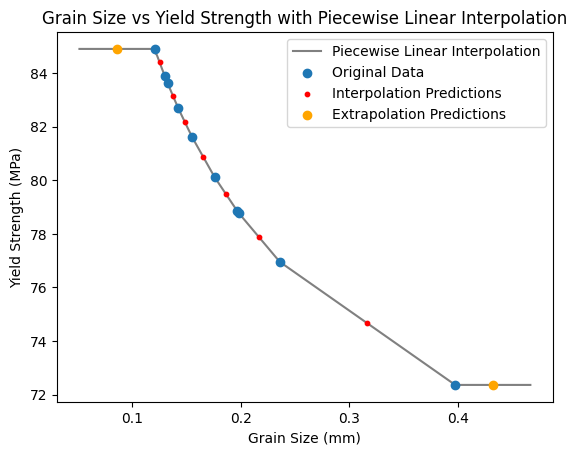

Grain Size (mm) Yield Strength (MPa)
        0.12555              84.3947
        0.13765             83.16265
         0.1488             82.16535
         0.1656              80.8713
         0.1864             79.48795
          0.217              77.8697
        0.31655             74.65945
                                    
       0.086362               84.901
       0.431737              72.3623


In [63]:
# interpolating spline Part 1
plot(*generate_points('Piecewise Linear Interpolation', wrap(np.interp, xp=x, fp=y), x, y))

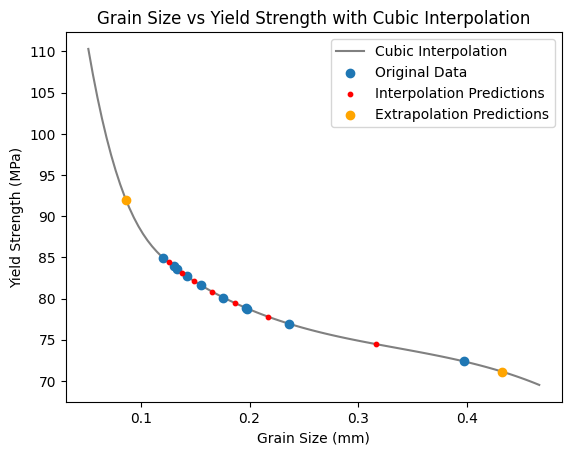

Grain Size (mm) Yield Strength (MPa)
        0.12555            84.374036
        0.13765            83.153097
         0.1488            82.146061
         0.1656            80.836274
         0.1864            79.464992
          0.217            77.796867
        0.31655            74.457577
                                    
       0.086362             91.99767
       0.431737            71.137554


In [64]:
# interpolating spline Part 2
from scipy.interpolate import CubicSpline
plot(*generate_points('Cubic Interpolation', CubicSpline(x, y), x, y))

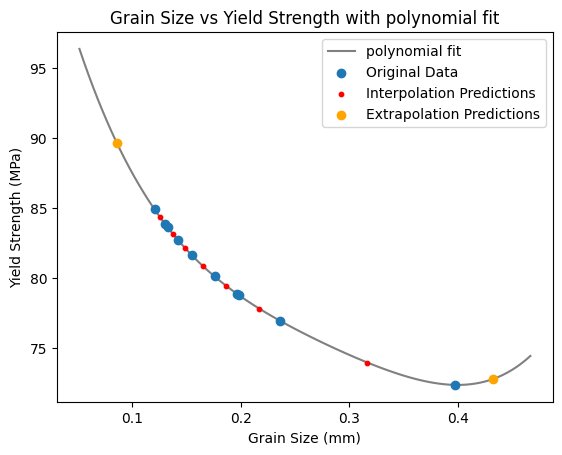

Grain Size (mm) Yield Strength (MPa)
        0.12555            84.382618
        0.13765            83.153739
         0.1488            82.148684
         0.1656            80.829718
         0.1864            79.458492
          0.217            77.817572
        0.31655            73.958124
                                    
       0.086362            89.618971
       0.431737            72.774762


In [65]:
# polynomial fit
plot(*generate_points('polynomial fit', np.poly1d(np.polyfit(x, y, 4)), x, y))

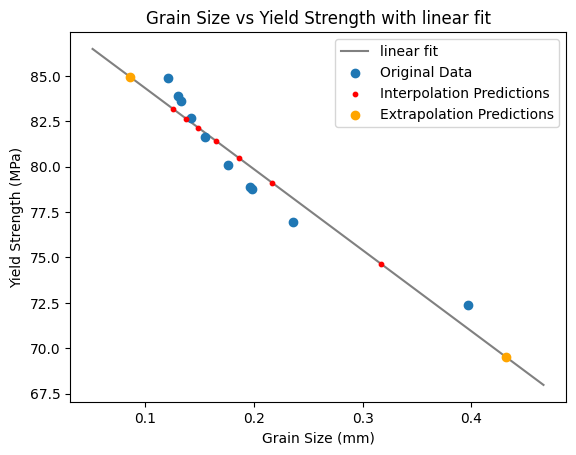

Grain Size (mm) Yield Strength (MPa)
        0.12555            83.196704
        0.13765            82.656101
         0.1488            82.157943
         0.1656            81.407354
         0.1864            80.478054
          0.217            79.110911
        0.31655            74.663227
                                    
       0.086362            84.947518
       0.431737            69.516893


In [66]:
# polynomial fit
plot(*generate_points('linear fit', np.poly1d(np.polyfit(x, y, 1)), x, y))

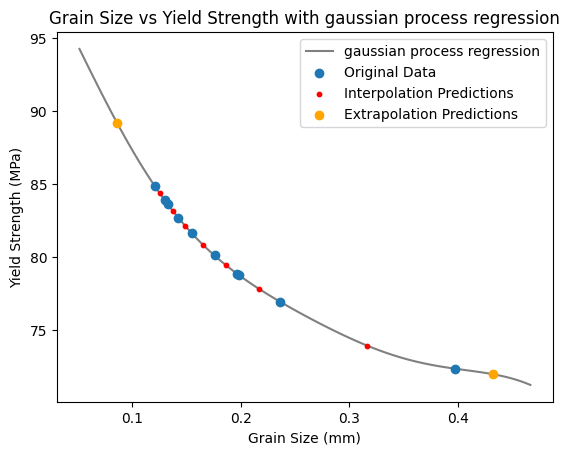

Grain Size (mm) Yield Strength (MPa)
        0.12555            84.379652
        0.13765            83.163488
         0.1488            82.155737
         0.1656            80.826892
         0.1864            79.451794
          0.217            77.820899
        0.31655            73.932965
                                    
       0.086362            89.190923
       0.431737              71.9865


In [67]:
# Ignore ConvergenceWarning from sklearn
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# gaussian process regression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

kernel = C(1.0, (1e-3, 1e3)) * RBF(1, (1e-2, 1e2)) + WhiteKernel(1e-1, (1e-3, 1e3))
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9).fit(x.reshape(-1, 1), y)

plot(*generate_points('gaussian process regression', model.predict, x, y, True))

In [68]:
from torch import nn
from fastai.tabular.all import TabularDataLoaders, tabular_learner

class Model(nn.Module):
	def __init__(self):
		super(Model, self).__init__()
		self.layers = nn.Sequential(
			nn.Linear(1, 10),
			nn.ReLU(),
			nn.Linear(10, 10),
			nn.ReLU(),
			nn.Linear(10, 1)
		)
	def forward(self, x):
		return self.layers(x)


data_loaders = TabularDataLoaders.from_df(data, cat_names=[], cont_names=['Mean Average Grain Size (mm)'], y_names=['Yield Strength (MPa)'], drop_last=False)
learner = tabular_learner(data_loaders)
with learner.no_logging():
    learner.fit_one_cycle(10000)

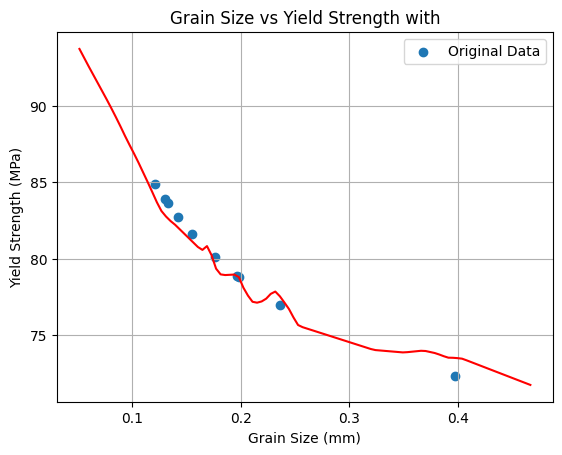

In [69]:
x_range = pd.DataFrame({'Mean Average Grain Size (mm)': _range(x)})

predictions = []
with learner.no_logging(), learner.no_bar():
    for index, row in x_range.iterrows():
        predictions.append(learner.predict(row)[2][0].item())

plt.plot(x_range, predictions, color='red')
plt.scatter(x, y, label='Original Data')
plt.xlabel('Grain Size (mm)')
plt.ylabel('Yield Strength (MPa)')
plt.legend()
plt.title(f'Grain Size vs Yield Strength with')
plt.grid(True)
plt.show()